# QA/QC pilot (dummy)

Minimal notebook to validate the automated QA/QC render loop: spin up the frisky/Dask cluster, open the production icechunk store at the injected `branch` for a single (scenario, variable, ensemble member), then render a `tas` time series at one point as a saved smoke-test artifact. The store is time-series chunked `(8000, 8, 16)`, so a point select reads only one spatial chunk across time -- cheap.

In [1]:
# papermill injects `branch` here at execution time
path_output = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
branch = "v0.10.0"
scenario = "historical"
var = "tas"
ens = "r1i1p1f1"

In [2]:
# Parameters
branch = "v0.10.0"


In [3]:
import frisky
import zarr
from distributed import Client

zarr.config.set({"async.concurrency": 128})

N_WORKERS = 16
client = frisky.hijack(Client(n_workers=N_WORKERS))
client

<frisky.Client: scheduler="127.0.0.1:33721" id="client-0">

In [4]:
from srm.utils import open_icechunk

group = f"{scenario}/{var}/{ens}"
ds = open_icechunk(path=path_output, branch=branch, group=group)
da = ds[var]
da

<xarray.DataArray 'tas' (time: 13514, lat: 721, lon: 1440)> Size: 56GB
dask.array<open_dataset-tas, shape=(13514, 721, 1440), dtype=float32, chunksize=(8000, 8, 16), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 108kB 1978-01-01 1978-01-02 ... 2014-12-31
  * lat      (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

=== Frisky Complete [127.0.0.1:33721] ===
  cluster: workers=16 memory=3.7 GiB/14.7 GiB (25%)
  tasks:   memory=1 finished=6
  network: 26.7 KiB  0%  27KB/s  8.9 KiB msgs


Text(0.5, 1.0, 'historical tas r1i1p1f1 @ v0.10.0  (37.8, -122.3)')

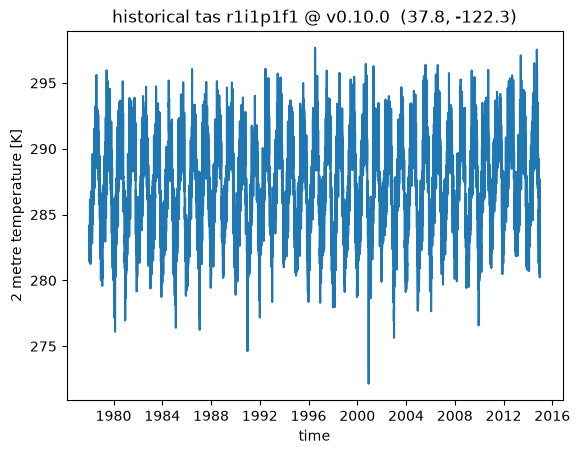

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

# Point time series: selecting a single lat/lon reads one spatial chunk across
# time (chunked (8000, 8, 16)), so this is cheap -- no load() needed.
lat, lon = 37.8, -122.3  # SF
da.sel(lat=lat, lon=lon, method="nearest").plot()
plt.title(f"{scenario} {var} {ens} @ {branch}  ({lat}, {lon})")